Importa a vista dos dados BR10Y e o transforma em um indice cujo valor inicial esta dado por a variavei indiceini


In [29]:
import sqlite3
import pandas as pd


# Conectar ao banco SQLite
conn = sqlite3.connect("sqtitulosinvesting.db")

# Ler a view como DataFrame
df = pd.read_sql_query("SELECT * FROM vwtitulosdados", conn)

# Fechar conexão
conn.close()

# Converter a coluna 'datetime' para datetime padrão
#df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
df["datetime"] = pd.to_datetime(df["datetime"], format="%Y-%m-%d %H:%M:%S", errors="coerce")




# Visualizar resultado
print(df.dtypes)
display(df.head())

symbol               object
moeda                object
intervalo            object
datetime     datetime64[ns]
open                float64
high                float64
low                 float64
close               float64
volume               object
dtype: object


,symbol,moeda,intervalo,datetime,open,high,low,close,volume
0,BR10Y,Taxa,diario,2025-09-16,13.663,13.675,13.630,13.630,None
1,BR10Y,Taxa,diario,2025-09-15,13.733,13.733,13.675,13.677,None
2,BR10Y,Taxa,diario,2025-09-12,13.813,13.823,13.797,13.797,None
3,BR10Y,Taxa,diario,2025-09-11,13.787,13.797,13.775,13.797,None
4,BR10Y,Taxa,diario,2025-09-10,13.890,13.890,13.833,13.837,None


In [31]:
df = df.sort_values(by="datetime", ascending=True).reset_index(drop=True)
display (df)


,symbol,moeda,intervalo,datetime,open,high,low,close,volume
0,BR10Y,Taxa,diario,2007-05-16,10.119,10.317,10.119,10.119,None
1,BR10Y,Taxa,diario,2007-05-17,9.927,10.119,9.927,9.927,None
2,BR10Y,Taxa,diario,2007-05-18,9.968,10.119,9.968,9.968,None
3,BR10Y,Taxa,diario,2007-05-21,9.868,9.968,9.868,9.868,None
4,BR10Y,Taxa,diario,2007-05-22,9.794,9.968,9.794,9.794,None
5,BR10Y,Taxa,diario,2007-05-24,10.170,10.170,10.170,10.170,None
6,BR10Y,Taxa,diario,2007-05-25,10.049,10.170,10.049,10.049,None
7,BR10Y,Taxa,diario,2007-05-28,10.036,10.049,10.036,10.036,None
8,BR10Y,Taxa,diario,2007-05-29,10.151,10.151,10.151,10.151,None
9,BR10Y,Taxa,diario,2007-05-30,10.158,10.158,10.158,10.158,None


In [32]:
#TIR bono 10 anos sim dividendo e amortização ao vencimento

import pandas as pd



# converter datetime e ordenar
df["datetime"] = pd.to_datetime(df["datetime"])
df = df.sort_values("datetime").reset_index(drop=True)

# converter yields (%) para decimal
for col in ["open","high","low","close"]:
    df[col+"_y"] = df[col] / 100

# maturidade em anos
T = 10

# calcular preços zero‐coupon (face value = 100)
for side in ["open","high","low","close"]:
    df[side+"_price"] = 100 * (1 + df[side+"_y"]) ** (-T)
    
# manter só colunas relevantes
price_cols = ["datetime"] + [c for c in df if c.endswith("_price")]
br10_prices = df[price_cols]

print(br10_prices.head())

    datetime  open_price  high_price  low_price  close_price
0 2007-05-16   38.139712   37.460673  38.139712    38.139712
1 2007-05-17   38.811126   38.139712  38.811126    38.811126
2 2007-05-18   38.666667   38.139712  38.666667    38.666667
3 2007-05-21   39.020049   38.666667  39.020049    39.020049
4 2007-05-22   39.283839   38.666667  39.283839    39.283839


In [35]:
#Calcular indice a partir de um indiceini  em uma dataini

import pandas as pd
df= br10_prices

df = df.sort_values("datetime").reset_index(drop=True)
df["datetime"] = pd.to_datetime(df["datetime"])

# Parâmetros
indiceini = 1000
dataini   = pd.to_datetime("2007-05-16")

# Acha posição da linha-base
base_idx = df.index[df["datetime"] == dataini]
if base_idx.empty:
    raise ValueError(f"Data {dataini.date()} não encontrada no DataFrame")
base_idx = base_idx[0]

# Novo DataFrame de índice
BR10 = pd.DataFrame({
    "symbol":    "BR10",
    "moeda":     "Índice",
    "intervalo": "diário",
    "datetime":  df["datetime"]
})

price_cols = ["open_price", "high_price", "low_price", "close_price"]

for col in price_cols:
    idx = pd.Series(index=df.index, dtype="float64")
    
    # valor base na data de referência
    idx.iloc[base_idx] = indiceini

    # 1) Propaga para frente
    for i in range(base_idx+1, len(df)):
        ratio = df[col].iloc[i] / df[col].iloc[i-1]
        idx.iloc[i] = idx.iloc[i-1] * ratio

    # 2) Propaga para trás
    for i in range(base_idx-1, -1, -1):
        ratio = df[col].iloc[i] / df[col].iloc[i+1]
        idx.iloc[i] = idx.iloc[i+1] * ratio

    # Renomeia coluna sem o sufixo "_price"
    new_name = col.replace("_price", "")
    BR10[new_name] = idx

# Reordena colunas
BR10 = BR10[["symbol", "moeda", "intervalo", "datetime", "open", "high", "low", "close"]]

# Ajuste de exibição (opcional)
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

display(BR10.head())

,symbol,moeda,intervalo,datetime,open,high,low,close
0,BR10,Índice,diário,2007-05-16,1000.000000,1000.000000,1000.000000,1000.000000
1,BR10,Índice,diário,2007-05-17,1017.604058,1018.126733,1017.604058,1017.604058
2,BR10,Índice,diário,2007-05-18,1013.816425,1018.126733,1013.816425,1013.816425
3,BR10,Índice,diário,2007-05-21,1023.081898,1032.193605,1023.081898,1023.081898
4,BR10,Índice,diário,2007-05-22,1029.998313,1032.193605,1029.998313,1029.998313


In [41]:
import sqlite3
import pandas as pd

# 1) Conectar ao banco SQLite
conn = sqlite3.connect("sqtitulosinvesting.db")

# 2) Preparar DataFrame para inserção
df_ins = BR10[["datetime","open","high","low","close"]].copy()

# definir id_titulosintervalos e volume
df_ins["id_titulosintervalos"] = 2
df_ins["volume"] = None

# garantir que datetime vire texto no formato ISO
df_ins["datetime"] = df_ins["datetime"].dt.strftime("%Y-%m-%d %H:%M:%S")

# 3) Inserir na tabela (append sem sobrescrever)
df_ins.to_sql(
    "tbtitulosprezos",
    conn,
    if_exists="append",
    index=False,
    dtype={
        "id_titulosintervalos": "INTEGER",
        "datetime": "TEXT",
        "open": "FLOAT",
        "high": "FLOAT",
        "low": "FLOAT",
        "close": "FLOAT",
        "volume": "FLOAT"
    }
)

# 4) Commit e fechar
conn.commit()
conn.close()

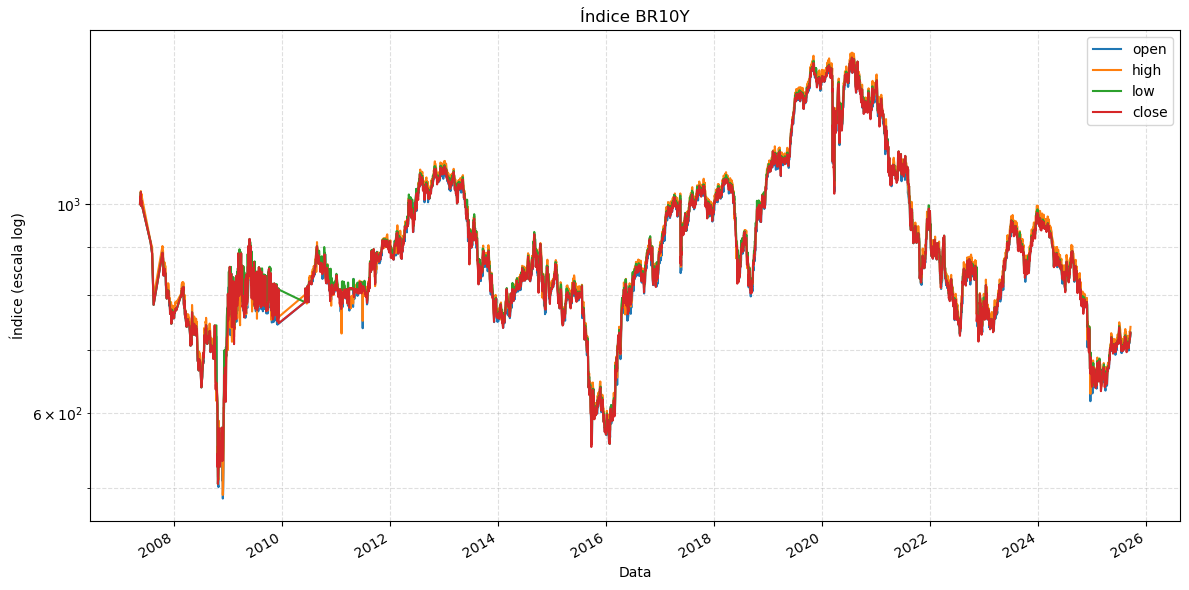

In [62]:
import matplotlib.pyplot as plt

# Supondo que BR10 seja seu DataFrame
BR10 = BR10.set_index("datetime")

# Seleciona apenas as colunas de preço
precos = BR10[["open", "high", "low", "close"]]

# Plota em log scale
ax = precos.plot(figsize=(12,6), logy=True)

ax.set_title("Índice BR10Y")
ax.set_ylabel("Índice (escala log)")
ax.set_xlabel("Data")
plt.xticks(rotation=30)
plt.grid(True, which="both", ls="--", alpha=0.4)
plt.tight_layout()
plt.show()

pip install mplfinance

C:\Users\scitr\AppData\Roaming\Python\Python312\site-packages\mplfinance\_arg_validators.py:84: UserWarning: 


            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.

  warnings.warn('\n\n ================================================================= '+
C:\Users\scitr\AppData\Local\Temp\ipykernel_24360\2944883502.py:23: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


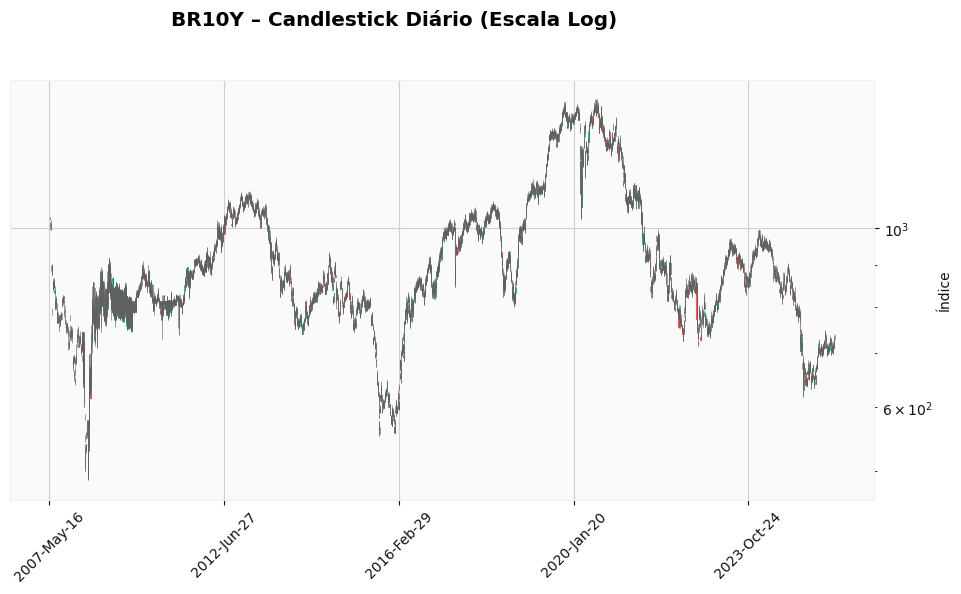

In [19]:
import mplfinance as mpf

# 1) Prepare o DataFrame com colunas no padrão Open/High/Low/Close
df_ohlc = BR10.set_index("datetime")[["open","high","low","close"]].copy()
df_ohlc.columns = ["Open","High","Low","Close"]

# 2) Gere o plot e capture figura/axes
fig, axes = mpf.plot(
    df_ohlc,
    type="candle",
    style="yahoo",
    title="BR10Y – Candlestick Diário (Escala Log)",
    ylabel="Índice",
    figsize=(12,6),
    returnfig=True
)

# 3) Ajuste o eixo Y para logarítmico no eixo principal (axes[0])
ax = axes[0]
ax.set_yscale("log")

# 4) Reajuste layout e mostre
fig.tight_layout()